# Digital Signals Theory

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

from IPython.display import display, Audio

import matplotlib as mpl

mpl.rcParams['axes.facecolor'] = '#f7f7f7'

## Chapter 7: DFT invertibility

### 7.3 Synthesis

In [2]:
fin = "bin/48224__slothrop__trumpetf3.wav"

print(sf.info(fin))

bin/48224__slothrop__trumpetf3.wav
samplerate: 44100 Hz
channels: 1
duration: 38912 samples
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]


In [3]:
raw_x, fs = sf.read(fin)

display("F3 on a trumpet")
display(Audio(data=raw_x, rate=fs))

'F3 on a trumpet'

#### Examining an ~11ms snippet

Using the `bin/48224__slothrop__trumpetf3.wav` sound file, we show the waveform for an approximately 11ms snippet, and its corresponding DFT magnitude spectrum.

In [4]:
x = raw_x[int(0.3*fs):  int(0.3*fs)+512]
t = np.arange(len(x))

X = np.fft.rfft(x)
mag_X = np.abs(X)

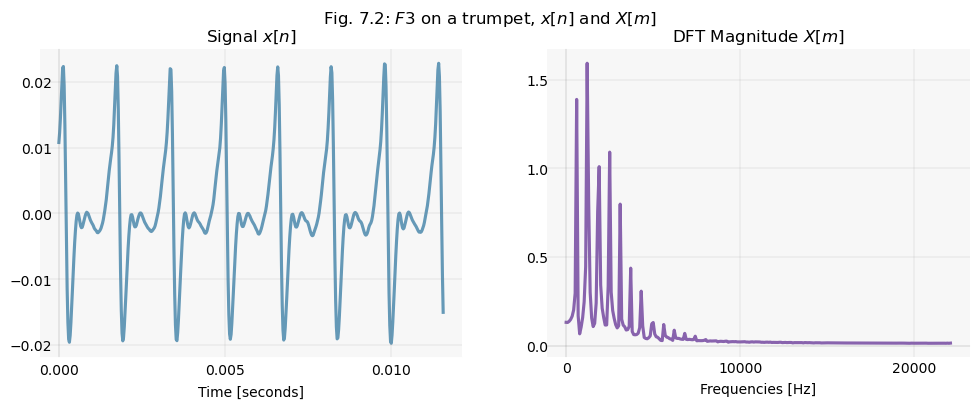

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# 1st plot for x in Time domain...
axes[0].plot(t, x, linewidth=2.25, color='#045a8d', alpha=0.6, zorder=-1)

axes[0].grid(True, linewidth=0.3, color='grey', alpha=0.4)
axes[0].set_title('Signal $x[n]$')
# Eliminate upper and right axes
axes[0].spines['right'].set_color('none')
axes[0].spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
axes[0].spines['left'].set_position('zero')
axes[0].spines['left'].set_color('grey')
axes[0].spines['left'].set_alpha(0.4)
axes[0].spines['left'].set_linewidth(0.3)
# Leave bottom x-axis, passing through center of plot
axes[0].spines['bottom'].set_color('#f7f7f7')
axes[0].spines['bottom'].set_alpha(0.4)
axes[0].spines['bottom'].set_linewidth(0.3)
axes[0].set_xlabel('Time [seconds]')
axes[0].xaxis.set_label_coords(0.5, -0.09)
axes[0].set_xticks([0, 221, 442], ['0.000', '0.005', '0.010'])
axes[0].tick_params(left=False, bottom=False, pad=1)

# -----------------------------------
# 2nd plot for the corresponding DFT
freq_idx = np.arange(X.size)
axes[1].plot(freq_idx, mag_X, linewidth=2.25, color='#3f007d', alpha=0.6, zorder=-1)

axes[1].grid(True, linewidth=0.3, color='grey', alpha=0.4)
axes[1].set_title('DFT Magnitude $X[m]$')
# Eliminate upper and right axes
axes[1].spines['right'].set_color('none')
axes[1].spines['top'].set_color('none')
axes[1].spines['bottom'].set_color('none')

# Move left y-axis, passing through (0,0)
axes[1].spines['left'].set_position('zero')
axes[1].spines['left'].set_color('grey')
axes[1].spines['left'].set_alpha(0.4)
axes[1].spines['left'].set_linewidth(0.3)
axes[1].set_yticks([0., 0.5, 1.0, 1.5])
axes[1].tick_params(axis='y', which=u'both', length=5, color='#96969680')

# Move bottom x-axis, passing through center of plot
axes[1].spines['bottom'].set_position('zero')
axes[1].spines['bottom'].set_color('grey')
axes[1].spines['bottom'].set_alpha(0.4)
axes[1].spines['bottom'].set_linewidth(0.3)
axes[1].set_xlabel('Frequencies [Hz]')
axes[1].xaxis.set_label_coords(0.5, -0.08)
axes[1].set_xticks([0, 116, 232], ['0', '10000', '20000'])
axes[1].tick_params(left=False, bottom=False, pad=8)

plt.suptitle('Fig. 7.2: $F3$ on a trumpet, $x[n]$ and $X[m]$')
plt.show()

<hr width=40%/>

#### Constructing $x[n]$ from $X[m]$

* Key intuition is that adding more DFT coefficients when reconstructing signal $x[n]$ from $X[m]$ leads to increased accuracy.
* _This is data compression at work!_

In [6]:
_X = np.fft.fft(raw_x)

In [7]:
apparent_fund_freq = 667

data = [
    (10, apparent_fund_freq),
    (20, apparent_fund_freq*2),
    (40, apparent_fund_freq*5),
    (60, apparent_fund_freq*8),
    (_X.size, _X.size)
]

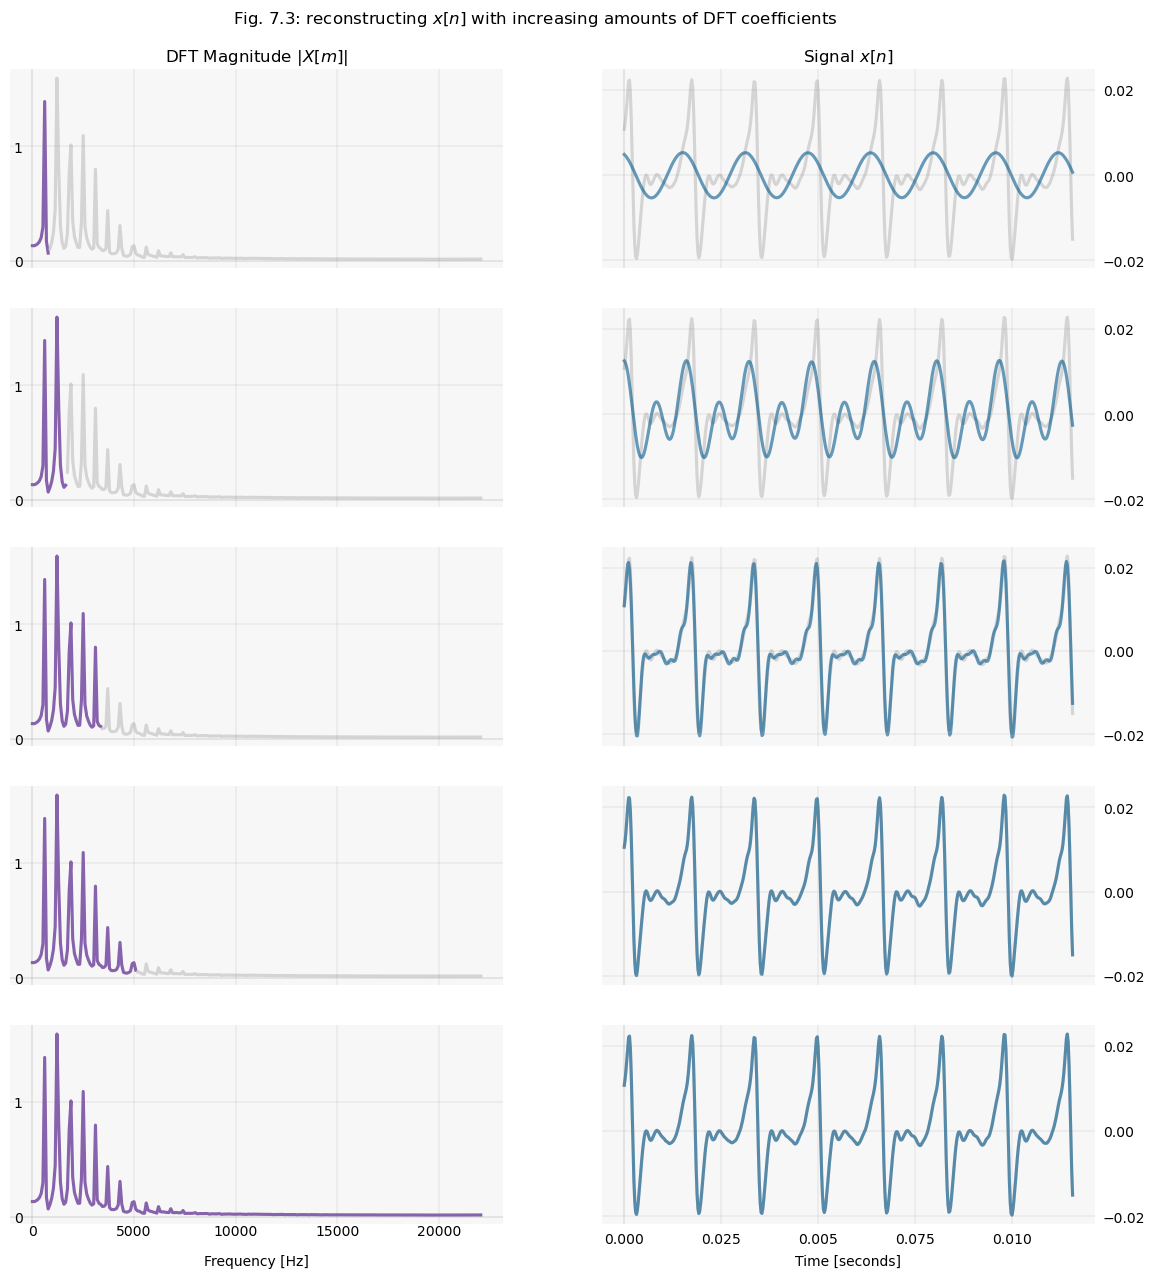

In [8]:
fig, axes = plt.subplots(nrows=len(data), ncols=2, figsize=(14, 15))

freq_idx = np.arange(X.size)


for i, (idx, fund_freq) in enumerate(data):

    mask = np.zeros(_X.size, dtype=np.complex128)
    mask[:fund_freq] = 1.
    mask[-fund_freq:] = 1.
    
    _x = np.fft.ifft(_X*mask)
    _x_trunc = np.real(_x[int(0.3*fs):  int(0.3*fs)+512])
    
    # -----------------------------------
    # 1st plot for the corresponding DFT
    
    axes[i,0].plot(freq_idx[:idx], mag_X[:idx], linewidth=2.25, color='#3f007d', alpha=0.6, zorder=-1)
    axes[i,0].plot(freq_idx[idx:], mag_X[idx:], linewidth=2.25, color='#bdbdbd', alpha=0.6, zorder=-1)
    
    axes[i,0].grid(True, linewidth=0.3, color='#737373', alpha=0.4)
    if i == 0:
        axes[i,0].set_title('DFT Magnitude $|X[m]|$')
    # Eliminate upper and right axes
    axes[i,0].spines['right'].set_color('none')
    axes[i,0].spines['top'].set_color('none')
    axes[i,0].spines['bottom'].set_color('none')
    
    # Move left y-axis, passing through (0,0)
    axes[i,0].spines['left'].set_position('zero')
    axes[i,0].spines['left'].set_color('grey')
    axes[i,0].spines['left'].set_alpha(0.4)
    axes[i,0].spines['left'].set_linewidth(0.3)
    axes[i,0].set_yticks([0, 1])
    axes[i,0].tick_params(axis='y', which=u'both', length=5, color='#96969680', pad=0)
    
    # Move bottom x-axis, passing through center of plot
    axes[i,0].spines['bottom'].set_position('zero')
    axes[i,0].spines['bottom'].set_color('grey')
    axes[i,0].spines['bottom'].set_alpha(0.4)
    axes[i,0].spines['bottom'].set_linewidth(0.3)
    if i != len(data)-1:
        axes[i,0].set_xticks([0, 58, 116, 174, 232], [])
    else:
        axes[i,0].set_xlabel('Frequency [Hz]')
        axes[i,0].xaxis.set_label_coords(0.5, -0.15)
        axes[i,0].set_xticks([0, 58, 116, 174, 232], ['0', '5000', '10000', '15000', '20000'])
    axes[i,0].tick_params(left=False, bottom=False, pad=2)
    
    # 2nd plot for x in time domain...
    axes[i,1].plot(t, x, linewidth=2.25, color='#bdbdbd', alpha=0.6, zorder=-1)
    axes[i,1].plot(t, _x_trunc, linewidth=2.25, color='#045a8d', alpha=0.6, zorder=-1)
    
    axes[i,1].grid(True, linewidth=0.3, color='#737373', alpha=0.4)
    if i == 0:
        axes[i,1].set_title('Signal $x[n]$')
    # Eliminate upper and right axes
    axes[i,1].spines['right'].set_color('none')
    axes[i,1].spines['top'].set_color('none')
    
    # Move left y-axis, passing through (0,0)
    axes[i,1].spines['left'].set_position('zero')
    axes[i,1].spines['left'].set_color('grey')
    axes[i,1].spines['left'].set_alpha(0.4)
    axes[i,1].spines['left'].set_linewidth(0.3)
    axes[i,1].yaxis.set_label_position('right')
    axes[i,1].yaxis.tick_right()
    axes[i,1].set_yticks([-0.02, 0.00, 0.02])
    # Leave bottom x-axis, passing through center of plot
    axes[i,1].spines['bottom'].set_color('#f7f7f7')
    axes[i,1].spines['bottom'].set_alpha(0.4)
    axes[i,1].spines['bottom'].set_linewidth(0.3)
    if i != len(data)-1:
        axes[i,1].set_xticks([0, 110, 221, 331, 442], [])
    else:
        axes[i,1].set_xlabel('Time [seconds]')
        axes[i,1].xaxis.set_label_coords(0.5, -0.15)
        axes[i,1].set_xticks([0, 110, 221, 331, 442], ['0.000', '0.025', '0.005', '0.075', '0.010'])
    axes[i,1].tick_params(left=False, right=False, bottom=False, pad=2)

plt.suptitle('Fig. 7.3: reconstructing $x[n]$ with increasing amounts of DFT coefficients', y=0.92)
plt.show()

----

### 7.4 Exercises

#### Exercise 7.1

Synthesize the following sample sinusoid by directly reconstructing its frequency domain representation $X[m]$ and then applying the _inverse DFT_.

Sample wave:

\begin{flalign}
\qquad x[n] &= A \cdot \cos(2\pi \cdot \text{f} \cdot \frac{n}{M} + \phi)  & \\\\
\end{flalign}

Recall that:

\begin{flalign}
\qquad X[m] &= A_{m} \cdot \frac{N}{2} \cdot e^{j \cdot \phi}  & \\\\
\qquad X[N-m] &= A_{m} \cdot \frac{N}{2} \cdot e^{-j \cdot \phi}  & \\\\
\end{flalign}

... from page 146.

In [9]:
# sampling rate
fs = 8000

# duration / number of frequencies 
N = 8000

# wave parameters
A = 5
f = 250    # Hz
phi = np.pi / 4

X = np.zeros(N, dtype=np.complex128)

# >>>
X[f]   = A * (N//2) * np.e**((0+1j)*phi)
X[N-f] = A * (N//2) * np.e**((0-1j)*phi)
# >>>

reconstructed_x = np.fft.ifft(X)

##### Let's generate the sample signal $x[n]$:

In [10]:
t = np.arange(N) / fs

theta = 2*np.pi * f * t

sample_x = A * np.cos(theta + phi)

##### Idiot-check!

Is sample signal $x[n]$ numerically close to our reconstructed version using the inverse DFT?

In [11]:
np.allclose(sample_x, reconstructed_x)

True

##### Visual check!

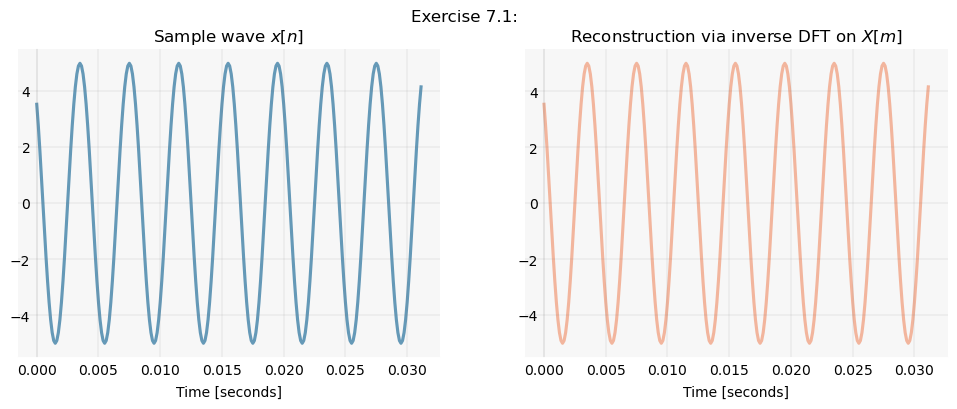

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# 1st plot for sample wave x 
axes[0].plot(t[:250], sample_x[:250], linewidth=2.25, color='#045a8d', alpha=0.6, zorder=-1)

axes[0].grid(True, linewidth=0.3, color='grey', alpha=0.4)
axes[0].set_title('Sample wave $x[n]$')
# Eliminate upper and right axes
axes[0].spines['right'].set_color('none')
axes[0].spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
axes[0].spines['left'].set_position('zero')
axes[0].spines['left'].set_color('grey')
axes[0].spines['left'].set_alpha(0.4)
axes[0].spines['left'].set_linewidth(0.3)
# Leave bottom x-axis, passing through center of plot
axes[0].spines['bottom'].set_color('#f7f7f7')
axes[0].spines['bottom'].set_alpha(0.4)
axes[0].spines['bottom'].set_linewidth(0.3)
axes[0].set_xlabel('Time [seconds]')
axes[0].xaxis.set_label_coords(0.5, -0.09)
axes[0].tick_params(left=False, bottom=False, pad=1)

# 2nd plot for sample wave x recreated from inverse DFT on X[m]
axes[1].plot(t[:250], np.real(reconstructed_x[:250]), linewidth=2.25, color='#ef8a62', alpha=0.6, zorder=-1)

axes[1].grid(True, linewidth=0.3, color='grey', alpha=0.4)
axes[1].set_title('Reconstruction via inverse DFT on $X[m]$')
# Eliminate upper and right axes
axes[1].spines['right'].set_color('none')
axes[1].spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
axes[1].spines['left'].set_position('zero')
axes[1].spines['left'].set_color('grey')
axes[1].spines['left'].set_alpha(0.4)
axes[1].spines['left'].set_linewidth(0.3)
# Leave bottom x-axis, passing through center of plot
axes[1].spines['bottom'].set_color('#f7f7f7')
axes[1].spines['bottom'].set_alpha(0.4)
axes[1].spines['bottom'].set_linewidth(0.3)
axes[1].set_xlabel('Time [seconds]')
axes[1].xaxis.set_label_coords(0.5, -0.09)
axes[1].tick_params(left=False, bottom=False, pad=1)


plt.suptitle('Exercise 7.1: ')
plt.show()

----

#### Exercise 7.2

##### Implementing a naive low-pass filter with $f_{T} = 500 \text{ Hz}$

Basic flow is:

1. Take some signal $x[n]$ of your choice
2. Calculate its DFT $X[m]$
3. Locate the frequency indices corresponding to $f_{T} = 500 \text{ Hz}$, and set these to 0
4. Calculate the _inverse DFT_ of this low-pass filtered $X[m]$, and see that _that_ sound like

<hr width=40%/>

##### 6s sample of A5 on a Korg synthesizer

c.f. [https://freesound.org/people/modularsamples/sounds/296349](https://freesound.org/people/modularsamples/sounds/296349/)

In [13]:
fin = "bin/296349__modularsamples__korg-z1-counting-a5-counting-81-127.wav"

fin_info = sf.info(fin)
print(fin_info)

bin/296349__modularsamples__korg-z1-counting-a5-counting-81-127.wav
samplerate: 44100 Hz
channels: 2
duration: 6.107 s
format: WAV (Microsoft) [WAV]
subtype: Signed 24 bit PCM [PCM_24]


In [14]:
stereo_x, fs = sf.read(fin)
mono_x = stereo_x[:,0]/2 + stereo_x[:,1]/2

display('A5 on a Korg synth (mono)')
display(Audio(data=mono_x, rate=fs))

'A5 on a Korg synth (mono)'

In [15]:
X = np.fft.fft(mono_x)
mag_X = np.abs(X)

N = int(fin_info.samplerate * fin_info.duration)
t = np.arange(N) / fin_info.samplerate

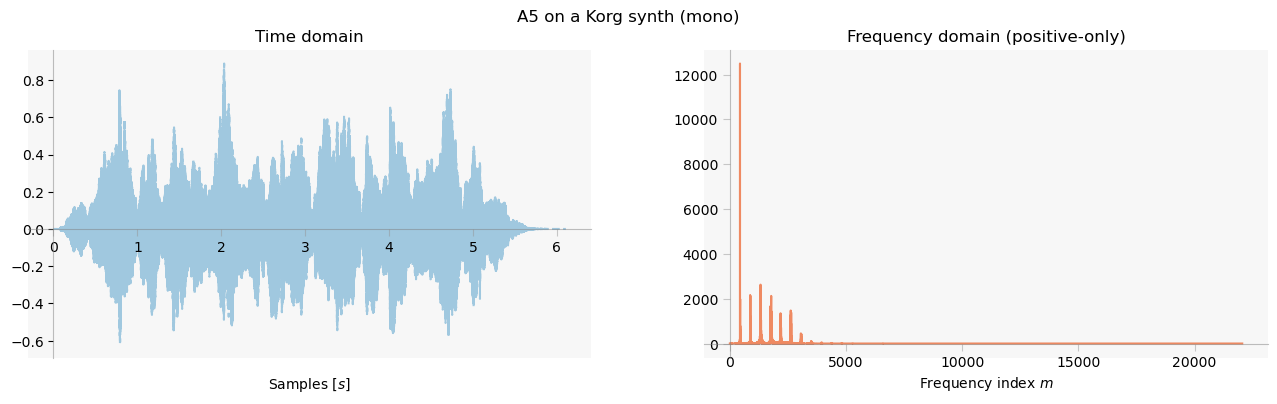

In [16]:
fig, (ax_time, ax_freq) = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

# 1st plot for the trumpet F3 waveform...
ax_time.plot(t, mono_x, color='#67a9cf', linestyle='--', alpha=0.6, zorder=-1)

ax_time.grid(False)
ax_time.set_title('Time domain')
# Eliminate upper and right axes
ax_time.spines['right'].set_color('none')
ax_time.spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_time.spines['left'].set_position('zero')
ax_time.spines['left'].set_color('grey')
ax_time.spines['left'].set_alpha(0.5)

# Move bottom x-axis, passing through center of plot
ax_time.spines['bottom'].set_position('zero')
ax_time.spines['bottom'].set_color('grey')
ax_time.spines['bottom'].set_alpha(0.5)
ax_time.set_xlabel('Samples $[s]$')
ax_time.xaxis.set_label_coords(0.5, -0.06)
ax_time.tick_params(axis='x', which=u'both', length=5, color='#96969680')

# -----------------------------------
# 2nd plot for the corresponding DFT 
freqs = (np.arange(X.size) / N) * fin_info.samplerate
ax_freq.plot(freqs[:N//2], mag_X[:N//2], color='#ef8a62')

ax_freq.grid(False)
ax_freq.set_title('Frequency domain (positive-only)')
# Eliminate upper and right axes
ax_freq.spines['right'].set_color('none')
ax_freq.spines['top'].set_color('none')
ax_freq.spines['bottom'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_freq.spines['left'].set_position('zero')
ax_freq.spines['left'].set_color('grey')
ax_freq.spines['left'].set_alpha(0.5)
ax_freq.tick_params(axis='y', which=u'both', length=5, color='#96969680')

# Move bottom x-axis, passing through center of plot
ax_freq.spines['bottom'].set_position('zero')
ax_freq.spines['bottom'].set_color('grey')
ax_freq.spines['bottom'].set_alpha(0.5)
ax_freq.set_xticks(np.arange(0, fin_info.samplerate//2, 5000))
ax_freq.set_xlabel('Frequency index $m$')
ax_freq.tick_params(axis='x', which=u'both', length=5, color='#96969680')

plt.suptitle('A5 on a Korg synth (mono)')
plt.show()

We now implement a naive low-pass filter with $f_{T} = 500 \text{ Hz}$ on this synth sound, and hear and see what happens...

In [17]:
# calculate where the 500 Hz cutoff frequency index is in X...
fT_idx = int(np.ceil( 500 / (fs / N) ))
print(f"frequency index for fT = 500 Hz should be: {fT_idx}")
print(f"-> idiot-check: fT * (fs/N) = {fT_idx*(fs/N)} Hz")

# set to 0 all frequencies in original DFT X[m] greater than fT and less than N - fT
X_lowpass = X.copy()
X_lowpass[fT_idx:N-fT_idx] = 0j
mag_X_lowpass = np.abs(X_lowpass)  # for our graph, in a bit..

# calculate inverse DFT on X with low-pass filter to (re)create the 
# original signal x[n] subject to low-pass filter with 500 Hz cutoff
x_lowpass = np.fft.ifft(X_lowpass)
x_lowpass = np.real(x_lowpass)

# now listen to this result..!
print()
display('A5 on a Korg synth (mono), but subjected to a low-pass filter with cut-off 500 Hz')
display(Audio(data=x_lowpass, rate=fs))

frequency index for fT = 500 Hz should be: 3054
-> idiot-check: fT * (fs/N) = 500.09431440114065 Hz



'A5 on a Korg synth (mono), but subjected to a low-pass filter with cut-off 500 Hz'

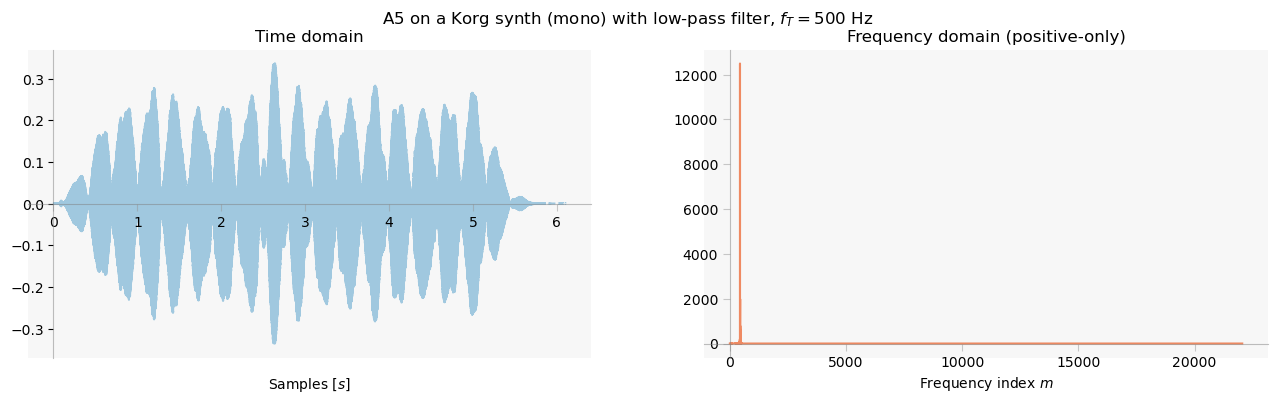

In [18]:
fig, (ax_time, ax_freq) = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

# 1st plot for the trumpet F3 waveform...
ax_time.plot(t, x_lowpass, color='#67a9cf', linestyle='--', alpha=0.6, zorder=-1)

ax_time.grid(False)
ax_time.set_title('Time domain')
# Eliminate upper and right axes
ax_time.spines['right'].set_color('none')
ax_time.spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_time.spines['left'].set_position('zero')
ax_time.spines['left'].set_color('grey')
ax_time.spines['left'].set_alpha(0.5)

# Move bottom x-axis, passing through center of plot
ax_time.spines['bottom'].set_position('zero')
ax_time.spines['bottom'].set_color('grey')
ax_time.spines['bottom'].set_alpha(0.5)
ax_time.set_xlabel('Samples $[s]$')
ax_time.xaxis.set_label_coords(0.5, -0.06)
ax_time.tick_params(axis='x', which=u'both', length=5, color='#96969680')

# -----------------------------------
# 2nd plot for the corresponding DFT 
freqs = (np.arange(X.size) / N) * fin_info.samplerate
ax_freq.plot(freqs[:N//2], mag_X_lowpass[:N//2], color='#ef8a62')

ax_freq.grid(False)
ax_freq.set_title('Frequency domain (positive-only)')
# Eliminate upper and right axes
ax_freq.spines['right'].set_color('none')
ax_freq.spines['top'].set_color('none')
ax_freq.spines['bottom'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_freq.spines['left'].set_position('zero')
ax_freq.spines['left'].set_color('grey')
ax_freq.spines['left'].set_alpha(0.5)
ax_freq.tick_params(axis='y', which=u'both', length=5, color='#96969680')

# Move bottom x-axis, passing through center of plot
ax_freq.spines['bottom'].set_position('zero')
ax_freq.spines['bottom'].set_color('grey')
ax_freq.spines['bottom'].set_alpha(0.5)
ax_freq.set_xticks(np.arange(0, fin_info.samplerate//2, 5000))
ax_freq.set_xlabel('Frequency index $m$')
ax_freq.tick_params(axis='x', which=u'both', length=5, color='#96969680')

plt.suptitle('A5 on a Korg synth (mono) with low-pass filter, $f_{T} = 500$ Hz')
plt.show()

<hr width=40%/>




c.f. [Applause small crowd 2](https://freesound.org/people/qubodup/sounds/169943/) at freesound. Audio recording 2012 Iwan Gabovitch [http://qubodup.net]

In [19]:
fin = "bin/169943__qubodup__applause-small-crowd-2.flac"

fin_info = sf.info(fin)
print(fin_info)

bin/169943__qubodup__applause-small-crowd-2.flac
samplerate: 44100 Hz
channels: 2
duration: 7.000 s
format: FLAC (Free Lossless Audio Codec) [FLAC]
subtype: Signed 24 bit PCM [PCM_24]


In [20]:
stereo_x, fs = sf.read(fin)
mono_x = stereo_x[:,0]/2 + stereo_x[:,1]/2

display('Cheers after a song at a small concert in Loophole club, Berlin, Germany. Recorded with a Zoom H2. (mono)')
display(Audio(data=mono_x, rate=fs))

'Cheers after a song at a small concert in Loophole club, Berlin, Germany. Recorded with a Zoom H2. (mono)'

In [21]:
X = np.fft.fft(mono_x)
mag_X = np.abs(X)

N = int(fin_info.samplerate * fin_info.duration)
t = np.arange(N) / fin_info.samplerate

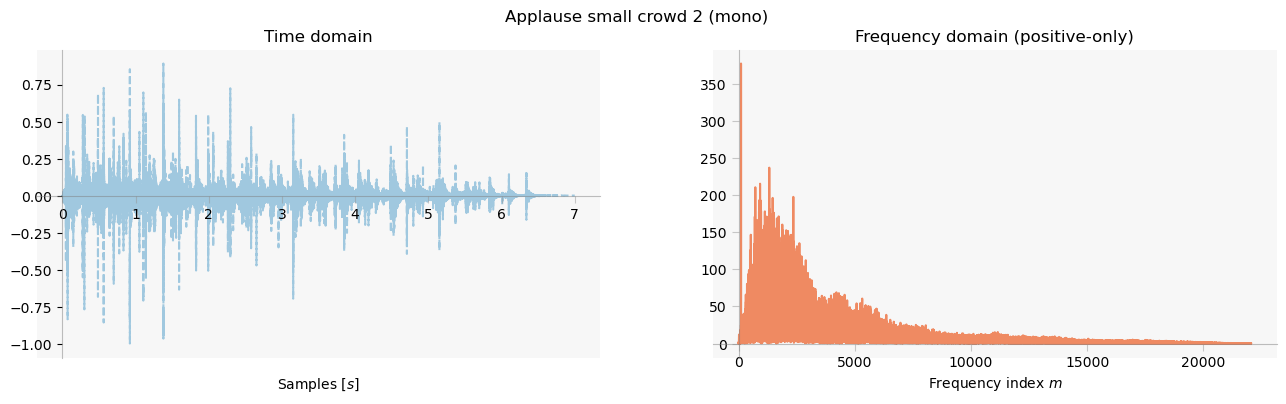

In [22]:
fig, (ax_time, ax_freq) = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

# 1st plot for the trumpet F3 waveform...
ax_time.plot(t, mono_x, color='#67a9cf', linestyle='--', alpha=0.6, zorder=-1)

ax_time.grid(False)
ax_time.set_title('Time domain')
# Eliminate upper and right axes
ax_time.spines['right'].set_color('none')
ax_time.spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_time.spines['left'].set_position('zero')
ax_time.spines['left'].set_color('grey')
ax_time.spines['left'].set_alpha(0.5)

# Move bottom x-axis, passing through center of plot
ax_time.spines['bottom'].set_position('zero')
ax_time.spines['bottom'].set_color('grey')
ax_time.spines['bottom'].set_alpha(0.5)
ax_time.set_xlabel('Samples $[s]$')
ax_time.xaxis.set_label_coords(0.5, -0.06)
ax_time.tick_params(axis='x', which=u'both', length=5, color='#96969680')

# -----------------------------------
# 2nd plot for the corresponding DFT 
freqs = (np.arange(X.size) / N) * fin_info.samplerate
ax_freq.plot(freqs[:N//2], mag_X[:N//2], color='#ef8a62')

ax_freq.grid(False)
ax_freq.set_title('Frequency domain (positive-only)')
# Eliminate upper and right axes
ax_freq.spines['right'].set_color('none')
ax_freq.spines['top'].set_color('none')
ax_freq.spines['bottom'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_freq.spines['left'].set_position('zero')
ax_freq.spines['left'].set_color('grey')
ax_freq.spines['left'].set_alpha(0.5)
ax_freq.tick_params(axis='y', which=u'both', length=5, color='#96969680')

# Move bottom x-axis, passing through center of plot
ax_freq.spines['bottom'].set_position('zero')
ax_freq.spines['bottom'].set_color('grey')
ax_freq.spines['bottom'].set_alpha(0.5)
ax_freq.set_xticks(np.arange(0, fin_info.samplerate//2, 5000))
ax_freq.set_xlabel('Frequency index $m$')
ax_freq.tick_params(axis='x', which=u'both', length=5, color='#96969680')

plt.suptitle('Applause small crowd 2 (mono)')
plt.show()

In [23]:
# calculate where the 500 Hz cutoff frequency index is in X...
fT_idx = int(np.ceil( 500 / (fs / N) ))
print(f"frequency index for fT = 500 Hz should be: {fT_idx}")
print(f"-> idiot-check: fT * (fs/N) = {fT_idx*(fs/N)} Hz")

# set to 0 all frequencies in original DFT X[m] greater than fT and less than N - fT
X_lowpass = X.copy()
X_lowpass[fT_idx:N-fT_idx] = 0j
mag_X_lowpass = np.abs(X_lowpass)  # for our graph, in a bit..

# calculate inverse DFT on X with low-pass filter to (re)create the 
# original signal x[n] subject to low-pass filter with 500 Hz cutoff
x_lowpass = np.fft.ifft(X_lowpass)
x_lowpass = np.real(x_lowpass)

# now listen to this result..!
print()
display('Cheers after a song at a small concert in Loophole club, Berlin, Germany (mono), but subjected to a low-pass filter with cut-off 500 Hz')
display(Audio(data=x_lowpass, rate=fs))

frequency index for fT = 500 Hz should be: 3500
-> idiot-check: fT * (fs/N) = 500.0 Hz



'Cheers after a song at a small concert in Loophole club, Berlin, Germany (mono), but subjected to a low-pass filter with cut-off 500 Hz'

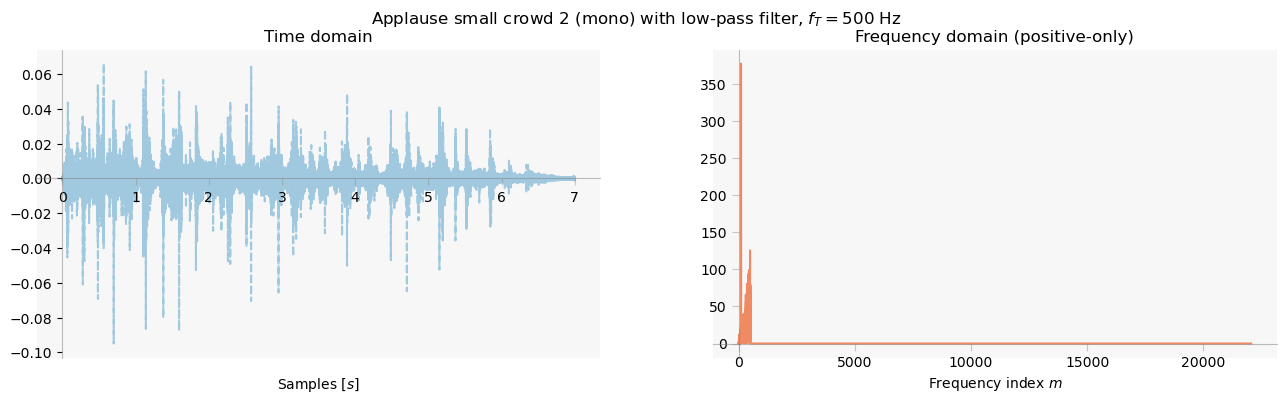

In [24]:
fig, (ax_time, ax_freq) = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

# 1st plot for the trumpet F3 waveform...
ax_time.plot(t, x_lowpass, color='#67a9cf', linestyle='--', alpha=0.6, zorder=-1)

ax_time.grid(False)
ax_time.set_title('Time domain')
# Eliminate upper and right axes
ax_time.spines['right'].set_color('none')
ax_time.spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_time.spines['left'].set_position('zero')
ax_time.spines['left'].set_color('grey')
ax_time.spines['left'].set_alpha(0.5)

# Move bottom x-axis, passing through center of plot
ax_time.spines['bottom'].set_position('zero')
ax_time.spines['bottom'].set_color('grey')
ax_time.spines['bottom'].set_alpha(0.5)
ax_time.set_xlabel('Samples $[s]$')
ax_time.xaxis.set_label_coords(0.5, -0.06)
ax_time.tick_params(axis='x', which=u'both', length=5, color='#96969680')

# -----------------------------------
# 2nd plot for the corresponding DFT 
freqs = (np.arange(X.size) / N) * fin_info.samplerate
ax_freq.plot(freqs[:N//2], mag_X_lowpass[:N//2], color='#ef8a62')

ax_freq.grid(False)
ax_freq.set_title('Frequency domain (positive-only)')
# Eliminate upper and right axes
ax_freq.spines['right'].set_color('none')
ax_freq.spines['top'].set_color('none')
ax_freq.spines['bottom'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_freq.spines['left'].set_position('zero')
ax_freq.spines['left'].set_color('grey')
ax_freq.spines['left'].set_alpha(0.5)
ax_freq.tick_params(axis='y', which=u'both', length=5, color='#96969680')

# Move bottom x-axis, passing through center of plot
ax_freq.spines['bottom'].set_position('zero')
ax_freq.spines['bottom'].set_color('grey')
ax_freq.spines['bottom'].set_alpha(0.5)
ax_freq.set_xticks(np.arange(0, fin_info.samplerate//2, 5000))
ax_freq.set_xlabel('Frequency index $m$')
ax_freq.tick_params(axis='x', which=u'both', length=5, color='#96969680')

plt.suptitle('Applause small crowd 2 (mono) with low-pass filter, $f_{T} = 500$ Hz')
plt.show()

----

#### Exercise 7.3

...